#MOSAIC Fusion Head Training


In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn import BCEWithLogitsLoss
from torch.optim import Adam
from sklearn.metrics import roc_auc_score


*Loading data*

---
Loading test and validated data per candidate (as csv) and the gw train, test val parquets for fusion head

In [ ]:
def read_merge(csv_path, parquet_path):
  rtf_output = pd.read_csv(csv_path)
  gw_map = pd.read_parquet(parquet_path)

  df = pd.merge(rtf_output, gw_map, on='object_id', how='inner')

  df = df.dropna()

  X = df[['rtf_score', 'gw_cred_level', 'gw_dp_dv']].values
  y = df['label'].values

  return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

*Creating Dataset and Dataloader*

In [ ]:
class gw_dataset(Dataset):
  def __init__(self, X, y):
    self.X = X
    self.y = y

  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]


X, y = read_merge('/content/train_set_rtf_scores.csv', '/content/train_gw_paired.parquet')

dataset = gw_dataset(X, y)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

*Initializing Fusion MLP*

In [ ]:
class FusionMLP(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Linear(3, 16)
    self.layer2 = nn.Linear(16, 16)
    self.layer3 = nn.Linear(16, 1)
    self.relu = nn.ReLU()

  def forward(self, x):
    x = self.relu(self.layer1(x))
    x = self.relu(self.layer2(x))
    x = self.layer3(x)
    return x
model = FusionMLP()
print(model)

FusionMLP(
  (layer1): Linear(in_features=3, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=16, bias=True)
  (layer3): Linear(in_features=16, out_features=1, bias=True)
  (relu): ReLU()
)


*Training Setup*

In [ ]:
criterion = BCEWithLogitsLoss()

optimizer = Adam(model.parameters(), lr=0.001)


*Training loop*

In [ ]:
epochs = 30

for i in range(epochs):
  model.train()
  for batch_x, batch_y in loader:
    optimizer.zero_grad()
    outputs = model(batch_x)
    outputs = outputs.squeeze(-1)
    batch_y = batch_y.float()
    loss = criterion(outputs, batch_y)
    loss.backward()
    optimizer.step()

  if (i+1) % 10 == 0:
    print(i+1, loss.item())
print("NaN in X:", torch.isnan(X).sum().item())
print("NaN in y:", torch.isnan(y).sum().item())
print("Any inf in X:", torch.isinf(X).sum().item())
torch.save(model.state_dict(), 'fusion_mlp.pt')

10 0.001090134377591312
20 0.0006064411718398333
30 0.0005269816028885543
NaN in X: 0
NaN in y: 0
Any inf in X: 0


In [ ]:
from sklearn.metrics import roc_auc_score

X_val, y_val = read_merge('/content/val_set_rtf_scores.csv', '/content/val_gw_paired.parquet')
val_dataset = gw_dataset(X_val, y_val)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch_x, batch_y in val_loader:
        preds = model(batch_x)
        preds = torch.sigmoid(preds.squeeze(-1))
        all_preds.extend(preds.numpy())
        all_labels.extend(batch_y.numpy())

auc = roc_auc_score(all_labels, all_preds)
print(f"Validation AUC: {auc:.4f}")

Validation AUC: 0.9972


In [ ]:
X_test, y_test = read_merge('/content/test_set_rtf_scores.csv', '/content/test_gw_paired.parquet')
test_dataset = gw_dataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        preds = model(batch_x)
        preds = torch.sigmoid(preds.squeeze(-1))
        all_preds.extend(preds.numpy())
        all_labels.extend(batch_y.numpy())

auc = roc_auc_score(all_labels, all_preds)
print(f"Test AUC: {auc:.4f}")

Test AUC: 0.9939


In [ ]:
X_test, y_test = read_merge('/content/test_set_rtf_scores.csv', '/content/test_gw_paired.parquet')

for i, name in enumerate(['rtf_score', 'gw_cred_level', 'gw_dp_dv']):
    auc = roc_auc_score(y_test, X_test[:, i])
    print(f"{name} alone: {auc:.4f}")

rtf_score alone: 0.9873
gw_cred_level alone: 0.8210
gw_dp_dv alone: 0.9871


FUSION MODEL TEST METRICS
ROC AUC:           0.9939
Avg Precision:     0.9829

TPR at FPR=1%: 0.9545 (threshold=0.0319)
TPR at FPR=5%: 0.9747 (threshold=0.0034)
TPR at FPR=10%: 0.9848 (threshold=0.0014)

At threshold=0.5:
  Accuracy:  0.9855
  Precision: 0.9944
  Recall:    0.8939
  F1 Score:  0.9415
  TP: 177 | FP: 1 | FN: 21 | TN: 1320


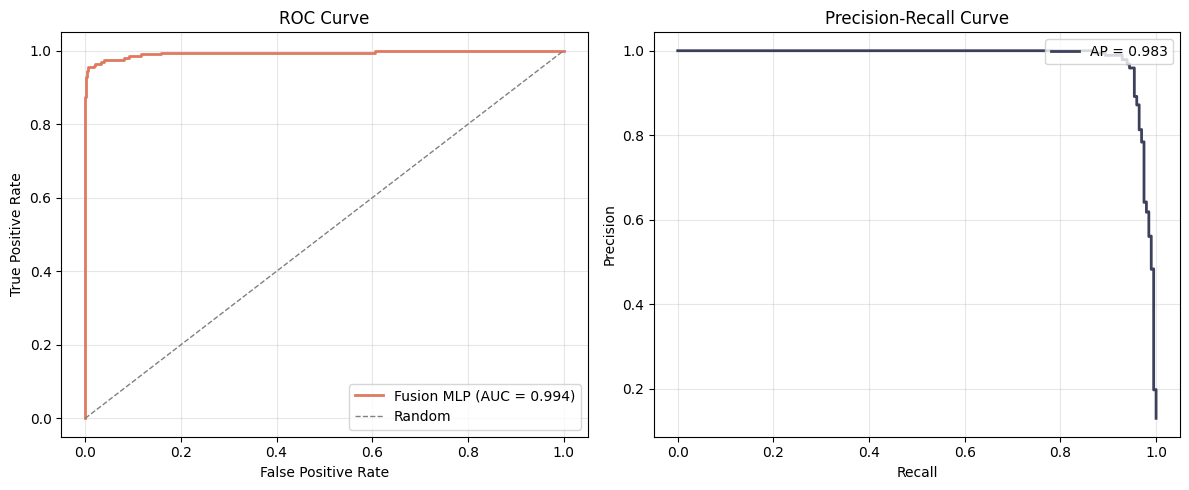

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, confusion_matrix

# Get all test predictions
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        preds = torch.sigmoid(model(batch_x).squeeze(-1))
        all_preds.extend(preds.numpy())
        all_labels.extend(batch_y.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# ROC
fpr, tpr, thresholds = roc_curve(all_labels, all_preds)
roc_auc = auc(fpr, tpr)

# Precision-Recall
precision, recall, pr_thresh = precision_recall_curve(all_labels, all_preds)
ap = average_precision_score(all_labels, all_preds)

# Print metrics
print("=" * 50)
print("FUSION MODEL TEST METRICS")
print("=" * 50)
print(f"ROC AUC:           {roc_auc:.4f}")
print(f"Avg Precision:     {ap:.4f}")
print()

# TPR at fixed FPR
for target_fpr in [0.01, 0.05, 0.10]:
    idx = np.where(fpr <= target_fpr)[0]
    if len(idx) > 0:
        i = idx[-1]
        print(f"TPR at FPR={target_fpr:.0%}: {tpr[i]:.4f} (threshold={thresholds[i]:.4f})")

print()

# Metrics at threshold 0.5
pred_binary = (all_preds >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(all_labels, pred_binary).ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision_50 = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_50 = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_50 = 2 * precision_50 * recall_50 / (precision_50 + recall_50) if (precision_50 + recall_50) > 0 else 0

print(f"At threshold=0.5:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision_50:.4f}")
print(f"  Recall:    {recall_50:.4f}")
print(f"  F1 Score:  {f1_50:.4f}")
print(f"  TP: {tp} | FP: {fp} | FN: {fn} | TN: {tn}")
print("=" * 50)

# Plot ROC
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr, tpr, color='#E07A5F', lw=2, label=f'Fusion MLP (AUC = {roc_auc:.3f})')
ax1.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

ax2.plot(recall, precision, color='#3D405B', lw=2, label=f'AP = {ap:.3f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fusion_metrics.png', dpi=200)
plt.show()

In [ ]:
# Get predictions with object_ids
X_test, y_test = read_merge('/content/test_set_rtf_scores.csv', '/content/test_gw_paired.parquet')
test_rtf = pd.read_csv('/content/test_set_rtf_scores.csv')
test_gw = pd.read_parquet('/content/test_gw_paired.parquet')
test_optical = pd.read_parquet('/content/test.parquet')

# Merge to get subclasses
merged = pd.merge(test_rtf, test_gw, on='object_id')
merged = merged.merge(test_optical[['objectId', 'subclass']].drop_duplicates(), left_on='object_id', right_on='objectId')

# Get predictions
model.eval()
with torch.no_grad():
    X_tensor = torch.tensor(merged[['rtf_score', 'gw_cred_level', 'gw_dp_dv']].values, dtype=torch.float32)
    merged['pred_prob'] = torch.sigmoid(model(X_tensor).squeeze(-1)).numpy()

# False positives only (label=0, pred>0.5)
fp = merged[(merged['label'] == 0) & (merged['pred_prob'] > 0.5)]
fp_counts = fp['subclass'].value_counts()
total_counts = merged[merged['label'] == 0]['subclass'].value_counts()

print("False Positives by Imposter Type:")
print("-" * 40)
for subtype in total_counts.index:
    n_fp = fp_counts.get(subtype, 0)
    n_total = total_counts[subtype]
    fp_rate = n_fp / n_total * 100 if n_total > 0 else 0
    print(f"{subtype:12s}: {n_fp:4d} / {n_total:4d} ({fp_rate:.1f}%)")

False Positives by Imposter Type:
----------------------------------------
E           :    0 /  318 (0.0%)
AGN         :    0 /  280 (0.0%)
SNIa        :    0 /  153 (0.0%)
RRL         :    0 /  149 (0.0%)
LPV         :    0 /  141 (0.0%)
QSO         :    0 /   68 (0.0%)
CV/Nova     :    1 /   64 (1.6%)
YSO         :    0 /   62 (0.0%)
Blazar      :    0 /   47 (0.0%)
SNII        :    0 /   27 (0.0%)
SLSN        :    0 /   11 (0.0%)
SNIbc       :    0 /    1 (0.0%)
